In [1]:
import numpy as np
import optuna
import torch
from torch.utils.data import DataLoader, TensorDataset, random_split
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
import copy

## Carga de datos de entrenamiento, división para obtener algunos de test y ampliación con transformaciones
En esta versión, **primero** se reconstruye cada imagen a tamaño **80x70**, **después** se aplican las transformaciones y **al final** se aplana para entrenar la red fully connected.


In [2]:
x_path = "X_train.npz"
y_path = "Y_train.npz"

def cargar_npz(ruta):
    data = np.load(ruta)
    
    # Si es un .npz, sacamos el primer array que contenga
    if isinstance(data, np.lib.npyio.NpzFile):
        if len(data.files) == 0:
            raise ValueError(f"El archivo {ruta} no contiene arrays")
        array = data[data.files[0]]
    else:
        array = data
    
    return array

try:
    X = cargar_npz(x_path)
    Y = cargar_npz(y_path)
except FileNotFoundError:
    raise ValueError("No se encuentran X_train.npz o Y_train.npz dentro de la carpeta datasets")
except Exception as e:
    raise ValueError(f"Error al cargar los datos: {e}")

print("Shape de X:", X.shape)
print("Shape de Y:", Y.shape)

Shape de X: (240, 5600)
Shape de Y: (240,)


In [3]:
# Pasar a tensores
X = torch.tensor(X, dtype=torch.float32)
Y = torch.tensor(Y, dtype=torch.long)

# Normalizar si son píxeles 0-255
X = X / 255.0

IMAGE_HEIGHT = 80
IMAGE_WIDTH = 70
IMAGE_SIZE = IMAGE_HEIGHT * IMAGE_WIDTH

def to_image_80x70(x):
    """Convierte una muestra en una imagen [1, 80, 70]."""
    if x.ndim == 1:
        if x.numel() != IMAGE_SIZE:
            raise ValueError(f"Se esperaban {IMAGE_SIZE} píxeles, pero llegaron {x.numel()}")
        return x.view(1, IMAGE_HEIGHT, IMAGE_WIDTH)

    if x.ndim == 2:
        if tuple(x.shape) != (IMAGE_HEIGHT, IMAGE_WIDTH):
            raise ValueError(f"Se esperaba una imagen de forma {(IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")
        return x.unsqueeze(0)

    if x.ndim == 3:
        if tuple(x.shape) == (1, IMAGE_HEIGHT, IMAGE_WIDTH):
            return x
        raise ValueError(f"Se esperaba una imagen de forma {(1, IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(x.shape)}")

    raise ValueError(f"Forma de imagen no soportada: {tuple(x.shape)}")

def flatten_image(img):
    """Aplana una imagen [1, 80, 70] a un vector de 5600 componentes."""
    if tuple(img.shape) != (1, IMAGE_HEIGHT, IMAGE_WIDTH):
        raise ValueError(f"Se esperaba una imagen de forma {(1, IMAGE_HEIGHT, IMAGE_WIDTH)}, pero llegó {tuple(img.shape)}")
    return img.reshape(-1)

rotation_transform = transforms.RandomRotation((10, 10))
horizontal_flip_transform = transforms.RandomHorizontalFlip(p=1.0)

# Dataset base con entradas y etiquetas
dataset = TensorDataset(X, Y)


In [4]:
generator = torch.Generator().manual_seed(42)
train_dataset_base, test_dataset = random_split(dataset, [180, 60], generator=generator)

def augment_training_subset(subset):
    x_augmented = []
    y_augmented = []

    for x, y in subset:
        img = to_image_80x70(x)

        # Imagen original (ya montada en 80x70 y luego aplanada)
        x_augmented.append(flatten_image(img))
        y_augmented.append(y)

        # Nueva imagen rotada +10 grados
        rotated_img = rotation_transform(img)
        x_augmented.append(flatten_image(rotated_img))
        y_augmented.append(y)

        # Nueva imagen con espejo horizontal
        flipped_img = horizontal_flip_transform(img)
        x_augmented.append(flatten_image(flipped_img))
        y_augmented.append(y)

    return TensorDataset(torch.stack(x_augmented), torch.stack(y_augmented))

def flatten_subset(subset):
    x_flattened = []
    y_flattened = []

    for x, y in subset:
        img = to_image_80x70(x)
        x_flattened.append(flatten_image(img))
        y_flattened.append(y)

    return TensorDataset(torch.stack(x_flattened), torch.stack(y_flattened))

train_dataset = augment_training_subset(train_dataset_base)
test_dataset = flatten_subset(test_dataset)

N_training = len(train_dataset)
N_test = len(test_dataset)

print("Total original:", len(dataset))
print("Train original:", len(train_dataset_base))
print("Train con augmentación:", len(train_dataset))
print("Test:", len(test_dataset))


Total original: 240
Train original: 180
Train con augmentación: 540
Test: 60


## Visualización de algunas imágenes tras las transformaciones
Ejecuta esta celda para comparar imágenes del conjunto de entrenamiento **ya reconstruidas a 80x70** con sus versiones rotadas y espejadas.


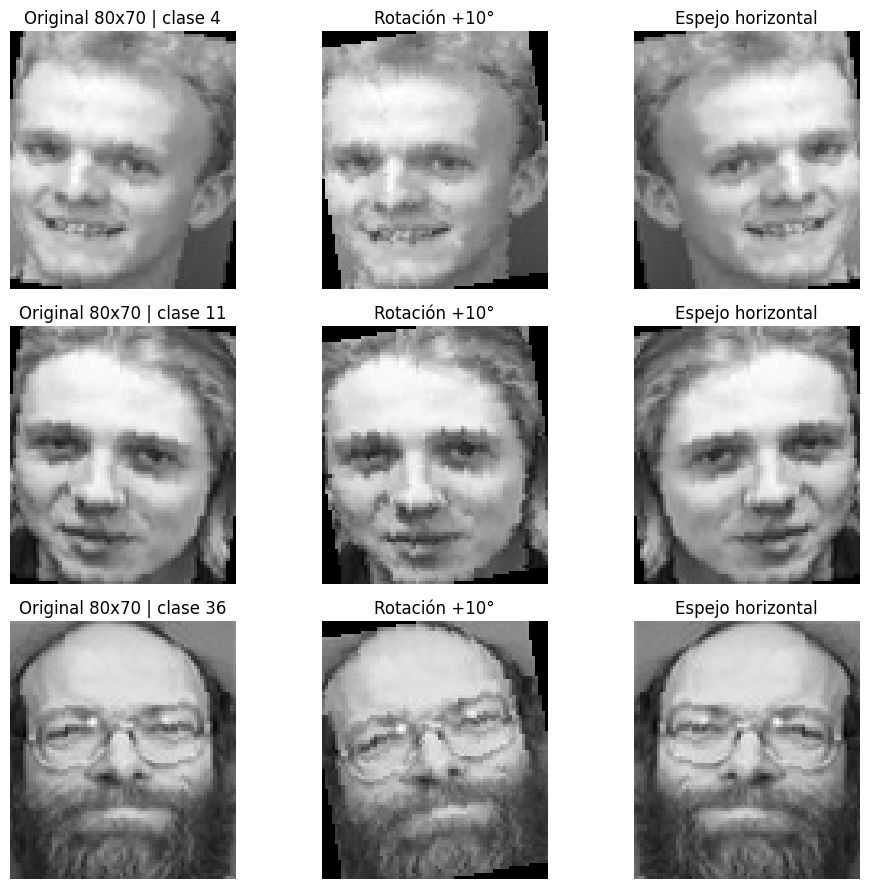

In [5]:
# Visualización de ejemplos de augmentación
num_examples = 3  # puedes cambiarlo si quieres ver más o menos ejemplos
indices = torch.randperm(len(train_dataset_base))[:num_examples]

fig, axes = plt.subplots(num_examples, 3, figsize=(10, 3 * num_examples))

if num_examples == 1:
    axes = np.expand_dims(axes, axis=0)

for row, idx in enumerate(indices):
    x, y = train_dataset_base[idx]
    img = to_image_80x70(x)

    original_img = img.squeeze(0).cpu().numpy()
    rotated_img = rotation_transform(img).squeeze(0).cpu().numpy()
    flipped_img = horizontal_flip_transform(img).squeeze(0).cpu().numpy()

    images = [original_img, rotated_img, flipped_img]
    titles = [f"Original 80x70 | clase {int(y)}", "Rotación +10°", "Espejo horizontal"]

    for col, (image, title) in enumerate(zip(images, titles)):
        axes[row, col].imshow(image, cmap="gray")
        axes[row, col].set_title(title)
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()


Definimos la funcion metric para medir el rendimiento de nuestro modelo

In [6]:
def linear_link(x):
    return x

class FCLayer(nn.Module):
    def __init__(self, dim_in, dim_out, act, drop, batch_norm, add_residual):
        super().__init__()
        ## create parameters
        self.linear = nn.Linear(dim_in, dim_out)
        self.act = act
        self.drop = nn.Dropout(p = drop)
        if batch_norm:
            self.bn = nn.BatchNorm1d(dim_out)
        else:
            self.bn = linear_link

        self.add_residual = add_residual
        # when residual is needed we need to readapt input
        if add_residual and dim_in != dim_out:
            self.bottleneck = nn.Linear(dim_in,dim_out)
        else:
            self.bottleneck = linear_link

        self.traced_grads = {}

    def forward(self, x):
        fx = self.drop(self.act(self.bn(self.linear(x))))
        if self.add_residual:
            fx = self.bottleneck(x) + fx
        return fx

    def trace_gradients(self):
        for k, v in self.named_parameters():
            if k in self.traced_grads.keys():
                self.traced_grads[k].append( v.grad.data.clone() )
            else:
                self.traced_grads[k] = [v.grad.data.clone()]

    def reset_traced_grads(self):
        self.traced_grads = {}

    def get_traced_grads(self):
        return self.traced_grads

class FCDNN(nn.Module):
    def __init__(self, dim_in, dim_out, neurons_hidden : list, hidden_activations:list, dropout_hidden, batch_norm: bool, add_residual:bool, link_function, loss_function):
        super().__init__()

        assert len(neurons_hidden) == len(hidden_activations), "List specifying hidden activations and number of hidden layers must coincide"
        assert len(neurons_hidden) == len(dropout_hidden), "List specifying hidden activations and dropout per layer"


        module_list = nn.ModuleList([])

        # input layer hidden layers
        for num_neur, act, drop in zip(neurons_hidden, hidden_activations, dropout_hidden):
            module_list.append(FCLayer(dim_in, num_neur, act, drop, batch_norm, add_residual))
            dim_in = num_neur

        # output layer
        o_layer = FCLayer(dim_in, dim_out, act = linear_link, drop = 0.0, batch_norm = False, add_residual = False)
        module_list.append(o_layer)

        self.layers = module_list

        ## Loss and link function
        self.link = link_function
        self.loss = loss_function

    def forward_train(self,x, apply_link):
        self.train()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def forward_eval(self,x, apply_link):
        self.eval()

        for l in self.layers:
            x = l(x)
        y = x
        if apply_link:
            y = self.link(y)

        return y

    def compute_loss(self,t,y):
        return self.loss(y,t)

    def get_internal_representations(self, x, apply_link):
        internals = {}
        # exclude output layer projection since this method gets internal representations
        for i, l in enumerate(self.layers[:-1]):
            x = l(x)
            internals[f'layer {i+1}']= x
        return internals

    def trace_gradients(self):
        for l in self.layers:
            l.trace_gradients()

    def reset_traced_grads(self):
        for l in self.layers:
            l.reset_traced_grads()

    def get_traced_grads(self):
        traced_grads = {}
        for i,l in enumerate(self.layers):
            traced_grads[f'layer {i+1}'] = l.get_traced_grads()

        return traced_grads

In [7]:
def compute_metric(dataloader, model):
    acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            acc += (t == torch.argmax(y, dim=1)).sum().item()
            tot_samples += len(t)

    return acc / tot_samples


def compute_metric_top3(dataloader, model, k=3):
    acc = compute_metric(dataloader, model)

    top_k_acc = 0
    tot_samples = 0

    model.eval()
    with torch.no_grad():
        for x, t in dataloader:
            x, t = x.to(device), t.to(device)
            y = model.forward_eval(x, apply_link=False)

            top_k_preds = torch.topk(y, k=k, dim=1).indices
            top_k_acc += top_k_preds.eq(t.view(-1, 1)).any(dim=1).sum().item()
            tot_samples += len(t)

    top_k_acc = top_k_acc / tot_samples
    global_metric = 0.7 * acc + 0.3 * top_k_acc

    return acc, top_k_acc, global_metric

In [8]:
def test_model(
    model : torch.nn.Module,
    epochs : int,
    train_batch_size : int,
    lr : float,
    betas : tuple,
    eps : float,
    mode : str,
    weight_decay : float,
    factor : float,
    patience : int,
    min_lr : float,
    mmu : float,
    apply_scheduler : bool,
    eval_each : int,
    train_dataset : torchvision.datasets,
    test_dataset : torchvision.datasets
):
    train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_eval = torch.utils.data.DataLoader(train_dataset, batch_size=train_batch_size, shuffle=False)
    test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=train_batch_size, shuffle=False)

    loss_epochs = []
    train_acc_epochs = []
    test_acc_epochs = []
    train_top3_epochs = []
    test_top3_epochs = []
    train_global_epochs = []
    test_global_epochs = []

    with torch.no_grad():
        loss_acc = 0.0
        for batch_idx, (x, t) in enumerate(train_loader_eval):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

        train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
        test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

    loss_epochs.append(loss_acc / N_training)
    train_acc_epochs.append(train_acc)
    test_acc_epochs.append(test_acc)
    train_top3_epochs.append(train_top3)
    test_top3_epochs.append(test_top3)
    train_global_epochs.append(train_global)
    test_global_epochs.append(test_global)

    # Guardar el mejor modelo según test_global
    best_metric = test_global
    best_epoch = 0
    best_state_dict = copy.deepcopy(model.state_dict())

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr,
        betas=betas,
        eps=eps,
        weight_decay=weight_decay
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode=mode,
        factor=factor,
        patience=patience,
        min_lr=min_lr
    )

    for e in range(epochs):
        model.train()
        loss_acc = 0.0

        for batch_idx, (x, t) in enumerate(train_loader):
            x, t = x.to(device), t.to(device)

            y = model.forward_train(x, apply_link=False)
            L = model.compute_loss(t, y)
            loss_acc += len(x) * L.item()

            L.backward()
            optimizer.step()
            optimizer.zero_grad()

            print(f"On epoch {e+1} batch_idx {batch_idx + 1} got loss {L.item():.5f}", end="\r")

        if (e + 1) % eval_each == 0 or e == 0:
            with torch.no_grad():
                train_acc, train_top3, train_global = compute_metric_top3(train_loader_eval, model, k=3)
                test_acc, test_top3, test_global = compute_metric_top3(test_loader, model, k=3)

            if apply_scheduler:
                scheduler.step(test_global)

            # Si mejora la métrica global en test, guardar checkpoint
            if test_global > best_metric:
                best_metric = test_global
                best_epoch = e + 1
                best_state_dict = copy.deepcopy(model.state_dict())

            print(" " * 300, end="\r")
            print(
                f"On epoch {e+1} got loss {loss_acc/N_training:.5f} "
                f"with train accuracy {train_acc:.5f}, train top3 {train_top3:.5f}, train global {train_global:.5f} "
                f"and test accuracy {test_acc:.5f}, test top3 {test_top3:.5f}, test global {test_global:.5f}"
            )
        else:
            print(" " * 300, end="\r")
            print(f"On epoch {e+1} got loss {loss_acc/N_training:.5f}")

        loss_epochs.append(loss_acc / N_training)
        train_acc_epochs.append(train_acc)
        test_acc_epochs.append(test_acc)
        train_top3_epochs.append(train_top3)
        test_top3_epochs.append(test_top3)
        train_global_epochs.append(train_global)
        test_global_epochs.append(test_global)

    # Restaurar el mejor modelo antes de salir
    model.load_state_dict(best_state_dict)

    return (
        loss_epochs,
        train_acc_epochs,
        test_acc_epochs,
        train_top3_epochs,
        test_top3_epochs,
        train_global_epochs,
        test_global_epochs
    )

Optuna

In [9]:
def objective(trial):
    torch.manual_seed(0)

    h1 = trial.suggest_categorical("h1", [128, 256, 512])
    h2 = trial.suggest_categorical("h2", [64, 128, 256])
    h3 = trial.suggest_categorical("h3", [64, 128, 256])

    d1 = trial.suggest_categorical("d1", [0.10, 0.15, 0.20, 0.25, 0.30, 0.40, 0.50])
    d2 = trial.suggest_categorical("d2", [0.10, 0.15, 0.20, 0.25, 0.30, 0.40])
    d3 = trial.suggest_categorical("d3", [0.05, 0.10, 0.15, 0.20, 0.25, 0.30])

    batch_norm = trial.suggest_categorical("batch_norm", [True, False])
    add_residual = trial.suggest_categorical("add_residual", [False, True])

    lr = trial.suggest_float("lr", 1e-4, 5e-3, log=True)
    beta1 = trial.suggest_float("beta1", 0.80, 0.95)
    beta2 = trial.suggest_float("beta2", 0.95, 0.9999)
    eps = trial.suggest_float("eps", 1e-9, 1e-7, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)
    train_batch_size = trial.suggest_categorical("train_batch_size", [32, 64, 128])
    factor = trial.suggest_float("factor", 0.1, 0.8)
    patience = trial.suggest_int("patience", 5, 25)
    min_lr = trial.suggest_float("min_lr", 1e-6, 1e-4, log=True)

    model = FCDNN(
        dim_in=5600,
        dim_out=40,
        neurons_hidden=[h1, h2, h3],
        hidden_activations=[torch.relu] * 3,
        dropout_hidden=[d1, d2, d3],
        batch_norm=batch_norm,
        add_residual=add_residual,
        link_function=lambda x: torch.softmax(x, dim=1),
        loss_function=nn.CrossEntropyLoss(),
    )
    model.to(device)

    (
        loss,
        train_acc,
        test_acc,
        train_top3,
        test_top3,
        train_global,
        test_global
    ) = test_model(
        model,
        epochs=200,
        lr=lr,
        betas=(beta1, beta2),
        eps=eps,
        weight_decay=weight_decay,
        mmu=0.8,
        train_batch_size=train_batch_size,
        apply_scheduler=True,
        mode='max',
        factor=factor,
        patience=patience,
        min_lr=min_lr,
        eval_each=1,
        train_dataset=train_dataset,
        test_dataset=test_dataset
    )

    best_epoch = int(np.argmax(test_global))
    best_test_global = float(test_global[best_epoch])

    trial.set_user_attr("best_epoch", best_epoch)
    trial.set_user_attr("best_test_acc", float(test_acc[best_epoch]))
    trial.set_user_attr("best_test_top3", float(test_top3[best_epoch]))

    return best_test_global

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

study = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=0)
)

study.optimize(objective, n_trials=5)

print("Mejor época:", study.best_trial.user_attrs["best_epoch"])
print("Mejor métrica global:", study.best_value)
print("Accuracy en esa época:", study.best_trial.user_attrs["best_test_acc"])
print("Top-3 en esa época:", study.best_trial.user_attrs["best_test_top3"])
print("Mejores hiperparámetros:", study.best_params)

[I 2026-04-16 20:47:37,515] A new study created in memory with name: no-name-107e8894-adbd-4a25-9268-fc5871235059


cuda
On epoch 1 got loss 3.96758 with train accuracy 0.03519, train top3 0.27407, train global 0.10685 and test accuracy 0.00000, test top3 0.15000, test global 0.04500                                                                                                                                         
On epoch 2 got loss 2.18074 with train accuracy 0.30185, train top3 0.48889, train global 0.35796 and test accuracy 0.15000, test top3 0.31667, test global 0.20000                                                                                                                                         
On epoch 3 got loss 1.24635 with train accuracy 0.64259, train top3 0.85556, train global 0.70648 and test accuracy 0.35000, test top3 0.61667, test global 0.43000                                                                                                                                         
On epoch 4 got loss 0.77938 with train accuracy 0.87222, train top3 0.97037, train global 0.

[I 2026-04-16 20:47:49,001] Trial 0 finished with value: 0.9033333333333333 and parameters: {'h1': 256, 'h2': 256, 'h3': 256, 'd1': 0.3, 'd2': 0.3, 'd3': 0.3, 'batch_norm': True, 'add_residual': True, 'lr': 0.0005956425742609301, 'beta1': 0.8852650923302973, 'beta2': 0.9509376110417741, 'eps': 1.71898067433194e-08, 'weight_decay': 0.0002807908107885729, 'train_batch_size': 64, 'factor': 0.3516555304016502, 'patience': 14, 'min_lr': 2.4846338168982413e-05}. Best is trial 0 with value: 0.9033333333333333.


On epoch 197 got loss 0.00000 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.95000, test global 0.89167                                                                                                                                       
On epoch 198 got loss 0.00000 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.95000, test global 0.89167                                                                                                                                       
On epoch 199 got loss 0.00000 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.95000, test global 0.89167                                                                                                                                       
On epoch 200 got loss 0.00000 with train accuracy 1.00000, train top3 1.00000, train global 1.000

[I 2026-04-16 20:48:01,105] Trial 1 finished with value: 0.8766666666666667 and parameters: {'h1': 512, 'h2': 256, 'h3': 128, 'd1': 0.1, 'd2': 0.25, 'd3': 0.3, 'batch_norm': False, 'add_residual': True, 'lr': 0.00011656787610079892, 'beta1': 0.8424210443864615, 'beta2': 0.9559978084045371, 'eps': 3.9109331722510605e-09, 'weight_decay': 2.984770033451217e-06, 'train_batch_size': 64, 'factor': 0.5847304835590139, 'patience': 16, 'min_lr': 3.3945247683628307e-06}. Best is trial 0 with value: 0.9033333333333333.


...

On epoch 199 got loss 0.00956 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.91667, test global 0.88167                                                                                                                                       
On epoch 200 got loss 0.00560 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.88333, test top3 0.91667, test global 0.89333                                                                                                                                       
On epoch 1 got loss 3.69330 with train accuracy 0.03333, train top3 0.20556, train global 0.08500 and test accuracy 0.00000, test top3 0.11667, test global 0.03500                                                                                                                                         
On epoch 2 got loss 2.22081 with train accuracy 0.03889, train top3 0.25741, train global 0.10444

[I 2026-04-16 20:48:25,699] Trial 3 finished with value: 0.8983333333333332 and parameters: {'h1': 256, 'h2': 256, 'h3': 256, 'd1': 0.2, 'd2': 0.3, 'd3': 0.05, 'batch_norm': True, 'add_residual': True, 'lr': 0.0005895972015841331, 'beta1': 0.9083083399205522, 'beta2': 0.9932324780638386, 'eps': 8.933939559063812e-08, 'weight_decay': 0.0026498016706379504, 'train_batch_size': 128, 'factor': 0.22014077408300836, 'patience': 15, 'min_lr': 1.2843280764272385e-06}. Best is trial 0 with value: 0.9033333333333333.


On epoch 196 got loss 0.00804 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.93333, test global 0.88667                                                                                                                                       
On epoch 197 got loss 0.00858 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.95000, test global 0.89167                                                                                                                                       
On epoch 198 got loss 0.00820 with train accuracy 1.00000, train top3 1.00000, train global 1.00000 and test accuracy 0.86667, test top3 0.93333, test global 0.88667                                                                                                                                       
On epoch 199 got loss 0.00761 with train accuracy 1.00000, train top3 1.00000, train global 1.000

[I 2026-04-16 20:48:34,807] Trial 4 finished with value: 0.48 and parameters: {'h1': 512, 'h2': 256, 'h3': 64, 'd1': 0.25, 'd2': 0.4, 'd3': 0.05, 'batch_norm': False, 'add_residual': False, 'lr': 0.00011013577680290942, 'beta1': 0.8100874447194873, 'beta2': 0.9839016993975785, 'eps': 8.079671227395437e-09, 'weight_decay': 0.0001400608779843278, 'train_batch_size': 64, 'factor': 0.5641547421700706, 'patience': 10, 'min_lr': 1.099770329950569e-06}. Best is trial 0 with value: 0.9033333333333333.


On epoch 198 got loss 1.51291 with train accuracy 0.74444, train top3 0.92037, train global 0.79722 and test accuracy 0.38333, test top3 0.63333, test global 0.45833                                                                                                                                       
On epoch 199 got loss 1.53372 with train accuracy 0.74259, train top3 0.91667, train global 0.79481 and test accuracy 0.38333, test top3 0.65000, test global 0.46333                                                                                                                                       
On epoch 200 got loss 1.50806 with train accuracy 0.74630, train top3 0.91667, train global 0.79741 and test accuracy 0.40000, test top3 0.65000, test global 0.47500                                                                                                                                       
Mejor época: 112
Mejor métrica global: 0.9033333333333333
Accuracy en esa época: 0.88333333333333

In [11]:
best = study.best_params

torch.manual_seed(0)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print("Usando:", device)
print("Hiperparámetros óptimos:", best)

model = FCDNN(
    dim_in=5600,
    dim_out=40,
    neurons_hidden=[best["h1"], best["h2"], best["h3"]],
    hidden_activations=[torch.relu] * 3,
    dropout_hidden=[best["d1"], best["d2"], best["d3"]],
    batch_norm=best["batch_norm"],
    add_residual=best["add_residual"],
    link_function=lambda x: torch.softmax(x, dim=1),
    loss_function=nn.CrossEntropyLoss(),
)
model.to(device)

(
    three_drop05_loss,
    three_drop05_train_acc,
    three_drop05_test_acc,
    three_drop05_train_top3,
    three_drop05_test_top3,
    three_drop05_train_global,
    three_drop05_test_global
) = test_model(
    model,
    epochs=400,
    lr=best["lr"],
    betas=(best["beta1"], best["beta2"]),
    eps=best["eps"],
    weight_decay=best["weight_decay"],
    mmu=0.8,
    train_batch_size=best["train_batch_size"],
    apply_scheduler=True,
    mode='max',
    factor=best["factor"],
    patience=best["patience"],
    min_lr=best["min_lr"],
    eval_each=1,
    train_dataset=train_dataset,
    test_dataset=test_dataset
)

best_epoch = int(np.argmax(three_drop05_test_global))
print("Best epoch:", best_epoch)
print("Best test global:", three_drop05_test_global[best_epoch])
print("Best test accuracy:", three_drop05_test_acc[best_epoch])
print("Best test top3:", three_drop05_test_top3[best_epoch])

Usando: cuda
Hiperparámetros óptimos: {'h1': 256, 'h2': 256, 'h3': 256, 'd1': 0.3, 'd2': 0.3, 'd3': 0.3, 'batch_norm': True, 'add_residual': True, 'lr': 0.0005956425742609301, 'beta1': 0.8852650923302973, 'beta2': 0.9509376110417741, 'eps': 1.71898067433194e-08, 'weight_decay': 0.0002807908107885729, 'train_batch_size': 64, 'factor': 0.3516555304016502, 'patience': 14, 'min_lr': 2.4846338168982413e-05}
On epoch 1 got loss 3.96758 with train accuracy 0.03519, train top3 0.27407, train global 0.10685 and test accuracy 0.00000, test top3 0.15000, test global 0.04500                                                                                                                                         
On epoch 2 got loss 2.18074 with train accuracy 0.30185, train top3 0.48889, train global 0.35796 and test accuracy 0.15000, test top3 0.31667, test global 0.20000                                                                                                                                  

In [12]:
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

n_test = len(test_dataset)
n_clases = 40

matriz_probs = torch.zeros((n_test, n_clases))
#matriz_probs_np = matriz_probs.numpy()   VERSION DE NUMPY, SI SE QUIERE USAR EN LUGAR DE TENSOR
#np.save("matriz_probs_test.npy", matriz_probs_np)   SIRVE PARA GUARDAR LA MATRIZ EN UN ARCHIVO .npy SI SE QUIERE USAR NUMPY EN LUGAR DE TENSOR

model.eval()

indice = 0
with torch.no_grad():
    for x, _ in test_loader:
        x = x.to(device)

        logits = model.forward_eval(x, apply_link=False)

        probs = torch.softmax(logits, dim=1).cpu()

        batch_size = probs.shape[0]
        matriz_probs[indice:indice + batch_size, :] = probs
        indice += batch_size

print(matriz_probs.shape)
print(matriz_probs)

torch.Size([60, 40])
tensor([[9.7413e-10, 3.0238e-07, 7.8119e-12,  ..., 4.3150e-15, 6.5630e-09,
         3.0686e-14],
        [1.5496e-09, 1.5778e-07, 1.7001e-13,  ..., 2.6040e-16, 7.8235e-09,
         7.5998e-16],
        [3.5315e-08, 3.7522e-09, 6.1186e-06,  ..., 4.6564e-01, 3.6378e-09,
         4.3311e-08],
        ...,
        [8.9718e-08, 1.2493e-10, 7.1533e-10,  ..., 9.1085e-07, 7.5444e-10,
         3.9618e-09],
        [3.4782e-07, 4.4935e-07, 1.7441e-08,  ..., 8.1721e-08, 3.5040e-11,
         1.0057e-08],
        [4.7429e-02, 4.0954e-05, 1.1144e-05,  ..., 5.4787e-07, 8.4813e-07,
         2.3035e-09]])


In [13]:
best_epoch = np.argmax(three_drop05_test_global)
best_test_acc = three_drop05_test_acc[best_epoch]
best_train_acc = three_drop05_train_acc[best_epoch]
best_loss = three_drop05_loss[best_epoch]


print(f"Mejor época: {best_epoch}")
print(f"Mejor test accuracy: {best_test_acc:.4f}")
print(f"Mejor test top3: {three_drop05_test_top3[best_epoch]:.4f}")
print(f"Mejor test global: {three_drop05_test_global[best_epoch]:.4f}")
print(f"Train accuracy en esa época: {best_train_acc:.4f}")
print(f"Train top3 en esa época: {three_drop05_train_top3[best_epoch]:.4f}")
print(f"Train global en esa época: {three_drop05_train_global[best_epoch]:.4f}")
print(f"Loss en esa época: {best_loss:.4f}")


Mejor época: 112
Mejor test accuracy: 0.8833
Mejor test top3: 0.9500
Mejor test global: 0.9033
Train accuracy en esa época: 1.0000
Train top3 en esa época: 1.0000
Train global en esa época: 1.0000
Loss en esa época: 0.0000


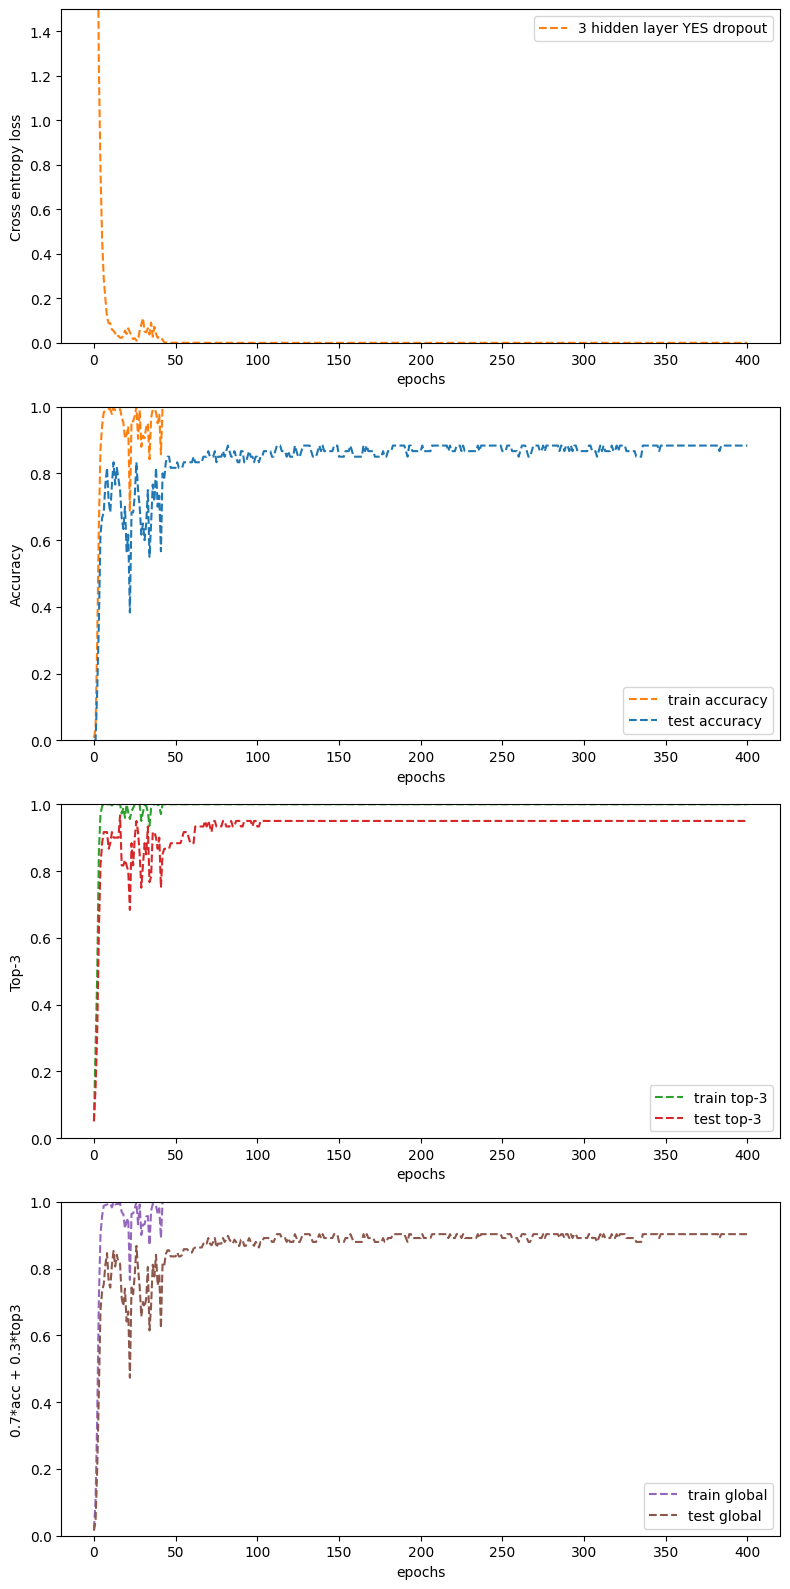

In [14]:
fig, (ax11, ax21, ax31, ax41) = plt.subplots(4, 1, figsize=(8, 16))

## Plot cross entropy loss
ax11.plot(range(len(three_drop05_loss)), three_drop05_loss,
          label='3 hidden layer YES dropout', color='C1', linestyle='--')
ax11.set_ylim([0.0, 1.5])
ax11.set_ylabel('Cross entropy loss')
ax11.set_xlabel('epochs')
ax11.legend()

## Plot accuracy (train y test)
ax21.plot(range(len(three_drop05_train_acc)), three_drop05_train_acc,
          label='train accuracy', color='C1', linestyle='--')
ax21.plot(range(len(three_drop05_test_acc)), three_drop05_test_acc,
          label='test accuracy', color='C0', linestyle='--')
ax21.set_ylim([0.0, 1.0])
ax21.set_ylabel('Accuracy')
ax21.set_xlabel('epochs')
ax21.legend()

## Plot top-3 (train y test)
ax31.plot(range(len(three_drop05_train_top3)), three_drop05_train_top3,
          label='train top-3', color='C2', linestyle='--')
ax31.plot(range(len(three_drop05_test_top3)), three_drop05_test_top3,
          label='test top-3', color='C3', linestyle='--')
ax31.set_ylim([0.0, 1.0])
ax31.set_ylabel('Top-3')
ax31.set_xlabel('epochs')
ax31.legend()

## Plot global metric (train y test)
ax41.plot(range(len(three_drop05_train_global)), three_drop05_train_global,
          label='train global', color='C4', linestyle='--')
ax41.plot(range(len(three_drop05_test_global)), three_drop05_test_global,
          label='test global', color='C5', linestyle='--')
ax41.set_ylim([0.0, 1.0])
ax41.set_ylabel('0.7*acc + 0.3*top3')
ax41.set_xlabel('epochs')
ax41.legend()

plt.tight_layout()
plt.show()